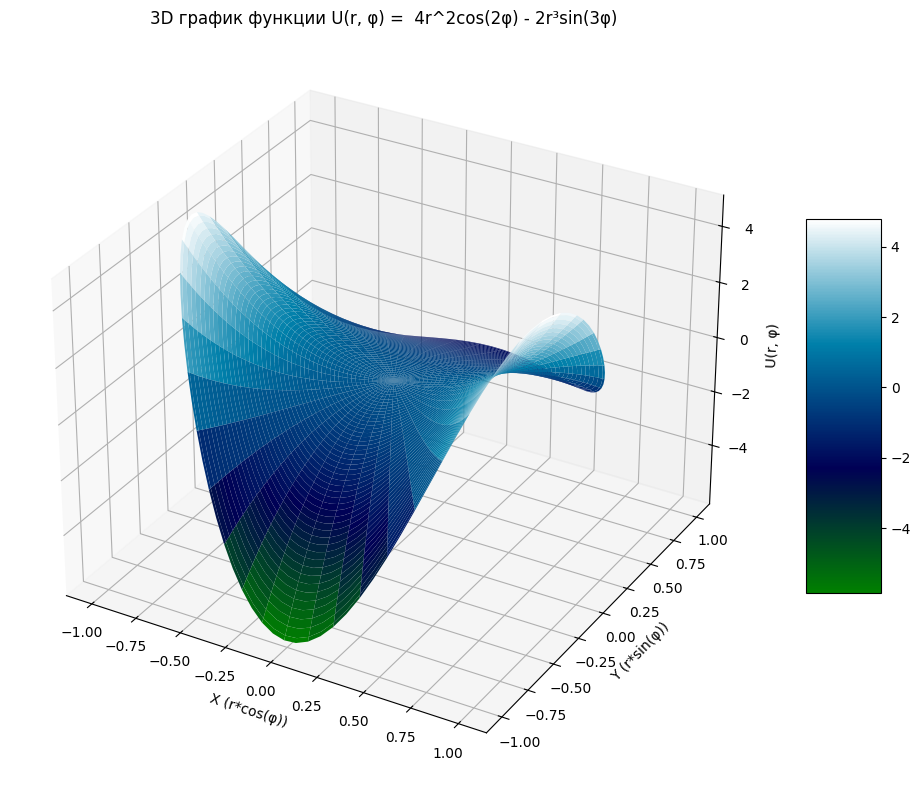

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Создаем сетку значений r и phi
r = np.linspace(0, 1, 100)
phi = np.linspace(0, 2 * np.pi, 100)
r, phi = np.meshgrid(r, phi)

# U(r, phi) из 9 номера
U = 4 * r ** 2 * np.cos(2 * phi) - 2 * r ** 3 * np.sin(3 * phi)

x = r * np.cos(phi)
y = r * np.sin(phi)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(x, y, U, cmap='ocean', edgecolor='none')
fig.colorbar(surf, ax=ax, shrink=0.5, aspect=5)

ax.set_xlabel('X (r*cos(φ))')
ax.set_ylabel('Y (r*sin(φ))')
ax.set_zlabel('U(r, φ)')
ax.set_title('3D график функции U(r, φ) =  4r^2cos(2φ) - 2r³sin(3φ)')

plt.tight_layout()
plt.show()

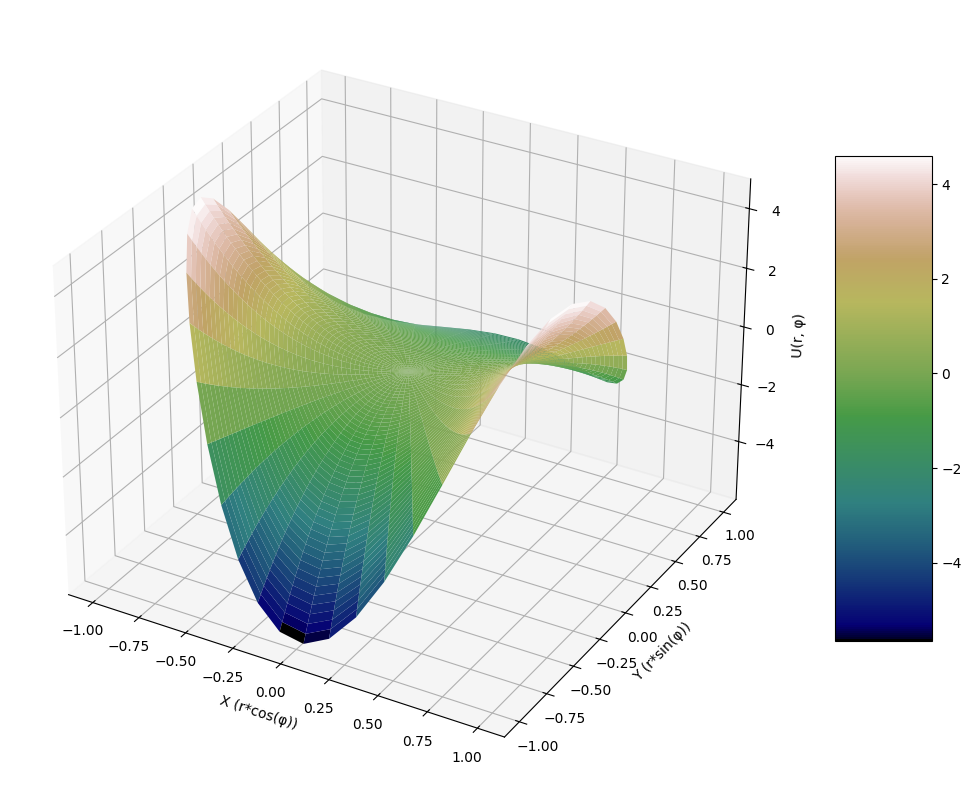

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad
from mpl_toolkits.mplot3d import Axes3D


def f(phi):
    return -2 * np.sin(3 * phi) + 4 * np.cos(2 * phi)


def inside(r, fi, a=1):
    integral = lambda psi: f(psi) * (a ** 2 - r ** 2) / (a ** 2 - 2 * a * r * np.cos(fi - psi) + r ** 2)
    result, error = quad(integral, 0, 2 * np.pi, epsabs=1e-10, epsrel=1e-10)
    return result / (2 * np.pi)


N = 50
r = np.linspace(0, 0.99, N)
fi = np.linspace(0, 2 * np.pi, N)
R, Fi = np.meshgrid(r, fi)
Z = np.zeros_like(R)

for i in range(N):
    for j in range(N):
        Z[i, j] = inside(R[i, j], Fi[i, j])

X = R * np.cos(Fi)
Y = R * np.sin(Fi)

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(X, Y, Z, cmap='gist_earth', linewidth=0, antialiased=True)
ax.set_xlabel('X (r*cos(φ))')
ax.set_ylabel('Y (r*sin(φ))')
ax.set_zlabel('U(r, φ)')
fig.colorbar(surf, shrink=0.5, aspect=5)
plt.tight_layout()
plt.show()

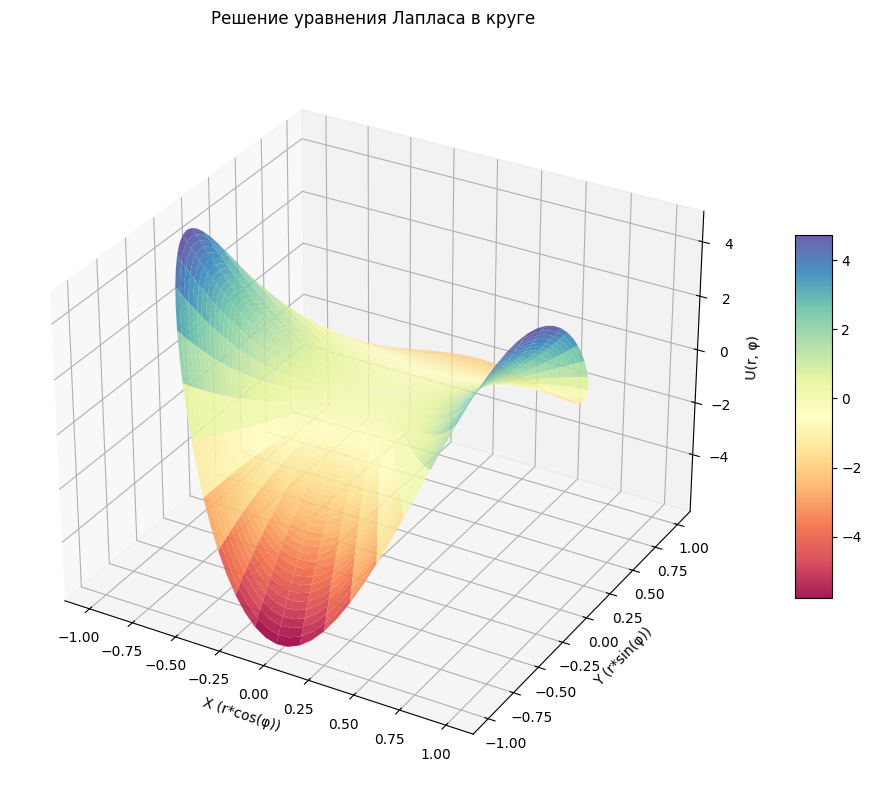

In [24]:
# Fourier

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

a = 1.0  # радиус
n_terms = 20  #  гармоники


def Ur_boundary(phi):
    return -2 * np.sin(3 * phi) + 4 * np.cos(2 * phi)


def fourier_coeffs(n_terms):
    A = np.zeros(n_terms)
    B = np.zeros(n_terms)

    phi = np.linspace(0, 2 * np.pi, 1000)
    f = Ur_boundary(phi)

    for n in range(n_terms):
        A[n] = np.trapz(f * np.cos(n * phi), phi) / np.pi
        B[n] = np.trapz(f * np.sin(n * phi), phi) / np.pi
        if n == 0:
            A[n] /= 2

    return A, B


# Получаем коэффициенты
A, B = fourier_coeffs(n_terms)


# Функция решения U(r, phi)
def U(r, phi):
    result = A[0] / 2
    for n in range(1, n_terms):
        result += r ** n * (A[n] * np.cos(n * phi) + B[n] * np.sin(n * phi))
    return result


# Создаем сетку
r_vals = np.linspace(0, 1, 50)
phi_vals = np.linspace(0, 2 * np.pi, 100)
r_grid, phi_grid = np.meshgrid(r_vals, phi_vals)

# Векторизуем функцию
U_vec = np.vectorize(U)

# Вычисляем значения
U_values = U_vec(r_grid, phi_grid)

# декартовы координаты
x = r_grid * np.cos(phi_grid)
y = r_grid * np.sin(phi_grid)

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(x, y, U_values, cmap='Spectral',
                       edgecolor='none', alpha=0.9)

ax.set_xlabel('X (r*cos(φ))')
ax.set_ylabel('Y (r*sin(φ))')
ax.set_zlabel('U(r, φ)')
ax.set_title('Решение уравнения Лапласа в круге\n')
plt.colorbar(surf, ax=ax, shrink=0.5, aspect=10)
plt.tight_layout()
plt.show()